# d55: TS Guess Assembly, Software Architecture, And Molecule Construction

This notebook is the software-oriented companion to `d52`. It uses the same
one-substrate/one-catalyst example, but it shows both sides of the workflow:

```text
chemistry assembly:  substrate + catalyst + template roles -> TS guess row
software assembly:   screen dataframe -> tsguess functions -> embedded row -> Stepper input
```

Read it like an IKEA instruction sheet with the wiring diagram printed next to
each drawing. Each step shows the molecular object being assembled and the FRUST
module/function responsible for that transformation.

The notebook intentionally imports some private helpers from `frust.tsguess`.
Those imports are for teaching and debugging the architecture. User workflows
should use the public surface:

```python
components = ft.screen.read(...)
systems = ft.screen.expand(components)
ts_guesses = ft.screen.create_ts_guesses(systems)
```

## How To Inspect The 3D Panels

The 3D panels use FRUST's `MolTo3DGrid` viewer.

- Click an atom to toggle its atom index label.
- Ctrl-click two atoms to measure a distance.
- Shift-click three atoms to measure an angle.
- Highlighted atoms are the role or placement atoms discussed in the text.

In [1]:
from pathlib import Path
import inspect

import numpy as np
import pandas as pd
from IPython.display import SVG, display
from rdkit import Chem
from rdkit.Chem import AllChem, rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Geometry import Point3D

import frust as ft
from frust.constraints import render_xtb_constraints
from frust.tsguess import create_ts_guess_dataframes
from frust.tsguess.assembly import (
    _add_final_ts_bonds,
    _allowed_contact_pairs,
    _assemble_system_mol,
    _connectivity_bonds,
    _hard_placement_atom_indices,
    _placement_coord_map,
    _rows_for_system_rpos,
)
from frust.tsguess.embedding import embed_with_coord_map
from frust.tsguess.matching import (
    hydrogens_on_atom,
    match_catalyst_roles,
    mol_from_smiles,
    parse_rpos_value,
    substrate_hydrogen_for_rpos,
)
from frust.tsguess.specs import BUILTIN_TS_SPECS
from frust.vis.molecules import _row_to_mol

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

ROOT = Path.cwd()
if ROOT.name == "dev":
    ROOT = ROOT.parent

print(f"Working from: {ROOT}")

Working from: /Users/jacobmolinnielsen/Developer/FrustActivationProject/FRUST


In [2]:
ROLE_COLORS = {
    "cat_B": (0.1, 0.75, 0.15),
    "cat_N": (0.35, 0.35, 0.95),
    "substrate_C": (0.95, 0.55, 0.05),
    "cat_H": (0.95, 0.95, 0.95),
    "transfer_H": (1.0, 0.15, 0.15),
    "n_transfer_H": (0.7, 0.25, 0.95),
    "pin_B": (0.0, 0.75, 0.75),
}
HARD_COLOR = (1.0, 0.55, 0.05)
SOFT_COLOR = (0.1, 0.75, 0.95)


def embed_copy(mol, seed=0xF00D):
    out = Chem.Mol(mol)
    if out.GetNumConformers() == 0:
        AllChem.EmbedMolecule(out, randomSeed=seed, useRandomCoords=False)
    return out


def label_atoms(mol, labels):
    out = Chem.Mol(mol)
    for atom_idx, label in labels.items():
        out.GetAtomWithIdx(int(atom_idx)).SetProp("atomNote", str(label))
    return out


def label_roles(mol, roles):
    return label_atoms(
        mol,
        {int(atom_idx): f"{role}:{int(atom_idx)}" for role, atom_idx in roles.items()},
    )


def draw_2d(mol, title="", highlights=None, labels=None, width=690, height=450):
    draw_mol = Chem.Mol(mol)
    if labels:
        for atom_idx, label in labels.items():
            draw_mol.GetAtomWithIdx(int(atom_idx)).SetProp("atomNote", str(label))
    rdDepictor.SetPreferCoordGen(True)
    rdDepictor.Compute2DCoords(draw_mol)

    atom_colors = {}
    if highlights:
        for atom_idx, color in highlights.items():
            atom_colors[int(atom_idx)] = tuple(color[:3])

    drawer = rdMolDraw2D.MolDraw2DSVG(width, height)
    opts = drawer.drawOptions()
    opts.addAtomIndices = True
    opts.annotationFontScale = 0.72
    opts.bondLineWidth = 2
    drawer.DrawMolecule(
        draw_mol,
        legend=title,
        highlightAtoms=list(atom_colors),
        highlightAtomColors=atom_colors,
    )
    drawer.FinishDrawing()
    display(SVG(drawer.GetDrawingText()))


def show_3d(mols, legends, highlights=None, columns=2, linked=True, size=(520, 430)):
    if not isinstance(mols, list):
        mols = [mols]
    if highlights is None:
        highlights = [[] for _ in mols]
    ft.MolTo3DGrid(
        [embed_copy(mol) for mol in mols],
        legends=legends,
        highlightAtoms=highlights,
        show_labels=True,
        show_confs=False,
        columns=columns,
        linked=linked,
        cell_size=size,
        kekulize=True,
        show_charges=True,
    )


def row_to_role_mol(row, coord_col="coords_embedded"):
    mol = _row_to_mol(row, row["atoms"], row[coord_col])
    return label_roles(mol, row["constraint_roles"])


def role_table(roles, mol):
    return pd.DataFrame(
        [
            {
                "role": role,
                "atom_index": int(atom_idx),
                "element": mol.GetAtomWithIdx(int(atom_idx)).GetSymbol(),
            }
            for role, atom_idx in sorted(roles.items())
        ]
    )


def highlight_from_roles(roles):
    return {
        int(atom_idx): ROLE_COLORS.get(role, (0.9, 0.6, 0.0))
        for role, atom_idx in roles.items()
    }


def distance(coords, a, b):
    return float(np.linalg.norm(coords[int(a)] - coords[int(b)]))


def angle(coords, a, b, c):
    ba = coords[int(a)] - coords[int(b)]
    bc = coords[int(c)] - coords[int(b)]
    cosine = float(np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc)))
    cosine = max(-1.0, min(1.0, cosine))
    return float(np.degrees(np.arccos(cosine)))


def constraint_table(row, coord_col="coords_embedded"):
    roles = row["constraint_roles"]
    coords = np.asarray(row[coord_col], dtype=float)
    records = []
    for item in row["constraint_spec"]:
        role_names = list(item["roles"])
        atom_ids = [int(roles[role]) for role in role_names]
        if item["kind"] == "distance":
            measured = distance(coords, atom_ids[0], atom_ids[1])
        else:
            measured = angle(coords, atom_ids[0], atom_ids[1], atom_ids[2])
        records.append(
            {
                "kind": item["kind"],
                "roles": "-".join(role_names),
                "atoms": "-".join(str(i) for i in atom_ids),
                "target": round(float(item["value"]), 3),
                "measured": round(measured, 3),
                "delta": round(measured - float(item["value"]), 3),
            }
        )
    return pd.DataFrame(records)


def role_template_mol(spec):
    symbol_by_role = {
        "cat_B": "B",
        "cat_N": "N",
        "substrate_C": "C",
        "pin_B": "B",
        "cat_H": "H",
        "transfer_H": "H",
        "n_transfer_H": "H",
    }
    editable = Chem.RWMol()
    role_to_idx = {}
    for role in spec.role_coordinates:
        atom = Chem.Atom(symbol_by_role.get(role, "C"))
        atom.SetProp("atomNote", role)
        role_to_idx[role] = editable.AddAtom(atom)
    mol = editable.GetMol()
    mol.UpdatePropertyCache(strict=False)
    conf = Chem.Conformer(mol.GetNumAtoms())
    for role, idx in role_to_idx.items():
        x, y, z = spec.role_coordinates[role]
        conf.SetAtomPosition(int(idx), Point3D(float(x), float(y), float(z)))
    mol.AddConformer(conf, assignId=True)
    return mol, role_to_idx


def function_signature(func):
    return f"{func.__name__}{inspect.signature(func)}"

## Step 1. Open The Software Box

The implementation has two layers:

1. `frust.screen` is the public dataframe interface. It reads component tables,
   expands substrate/catalyst combinations, and calls the TS-guess generator.
2. `frust.tsguess` is the construction machinery. It parses chemistry roles,
   chooses a built-in template, assembles fragments, embeds coordinates, stores
   connectivity, and returns ordinary FRUST dataframe rows.

In [3]:
software_map = pd.DataFrame(
    [
        {
            "stage": "input normalization",
            "owner": "frust.screen.core.read",
            "receives": "CSV path or dataframe with role/smiles/rpos",
            "returns": "component dataframe",
        },
        {
            "stage": "combinatorial expansion",
            "owner": "frust.screen.core.expand",
            "receives": "component dataframe",
            "returns": "system dataframe with substrate/catalyst pairs",
        },
        {
            "stage": "public TS generation",
            "owner": "frust.screen.core.create_ts_guesses",
            "receives": "system dataframe + TS names",
            "returns": "dict[str, dataframe] grouped by TS type",
        },
        {
            "stage": "row orchestration",
            "owner": "frust.tsguess.assembly.create_ts_guess_dataframes",
            "receives": "systems, rpos values, TSSpec objects",
            "returns": "FRUST initial rows",
        },
        {
            "stage": "chemistry role matching",
            "owner": "frust.tsguess.matching",
            "receives": "SMILES-derived RDKit molecules",
            "returns": "role atom indices such as cat_B and substrate_C",
        },
        {
            "stage": "template data",
            "owner": "frust.tsguess.specs.BUILTIN_TS_SPECS",
            "receives": "TS name",
            "returns": "role coordinates, constraints, extra fragment rules",
        },
        {
            "stage": "coordinate embedding",
            "owner": "frust.tsguess.embedding.embed_with_coord_map",
            "receives": "assembled molecule + coord map",
            "returns": "embedded RDKit molecule + conformer ids",
        },
        {
            "stage": "quality diagnostics",
            "owner": "frust.tsguess.diagnostics.core_metrics",
            "receives": "coords + roles + constraints",
            "returns": "distance/angle deviations stored on the row",
        },
    ]
)
software_map

,stage,owner,receives,returns
0,input normalization,frust.screen.core.read,CSV path or dataframe with role/smiles/rpos,component dataframe
1,combinatorial expansion,frust.screen.core.expand,component dataframe,system dataframe with substrate/catalyst pairs
2,public TS generation,frust.screen.core.create_ts_guesses,system dataframe + TS names,"dict[str, dataframe] grouped by TS type"
3,row orchestration,frust.tsguess.assembly.create_ts_guess_dataframes,"systems, rpos values, TSSpec objects",FRUST initial rows
4,chemistry role matching,frust.tsguess.matching,SMILES-derived RDKit molecules,role atom indices such as cat_B and substrate_C
5,template data,frust.tsguess.specs.BUILTIN_TS_SPECS,TS name,"role coordinates, constraints, extra fragment rules"
6,coordinate embedding,frust.tsguess.embedding.embed_with_coord_map,assembled molecule + coord map,embedded RDKit molecule + conformer ids
7,quality diagnostics,frust.tsguess.diagnostics.core_metrics,coords + roles + constraints,distance/angle deviations stored on the row


## Step 2. Put The Chemical Parts On The Table

This is the same input as `d52`: one substrate SMILES, one catalyst SMILES, and
one chosen substrate reactive position. At this point FRUST has not built a TS;
we only have two separate chemical components.

In [4]:
substrate_smiles = "CN1C=CC=C1"
catalyst_smiles = "CC1(C)CCCC(C)(C)N1C2=CC=CC=C2B"
substrate_name = "n_methyl_pyrrole"
catalyst_name = "tmp_bcat"
chosen_rpos = 2
selected_ts = "TS3"

screen_input = pd.DataFrame(
    {
        "role": ["substrate", "catalyst"],
        "smiles": [substrate_smiles, catalyst_smiles],
        "compound_name": [substrate_name, catalyst_name],
        "rpos": [str(chosen_rpos), ""],
    }
)
screen_input

,role,smiles,compound_name,rpos
0,substrate,CN1C=CC=C1,n_methyl_pyrrole,2
1,catalyst,CC1(C)CCCC(C)(C)N1C2=CC=CC=C2B,tmp_bcat,


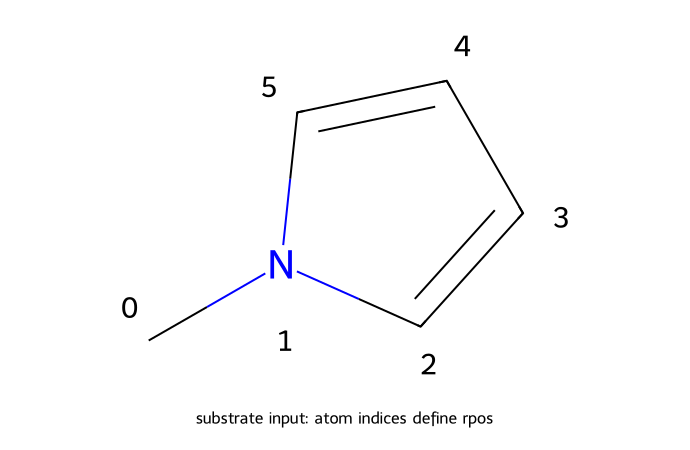

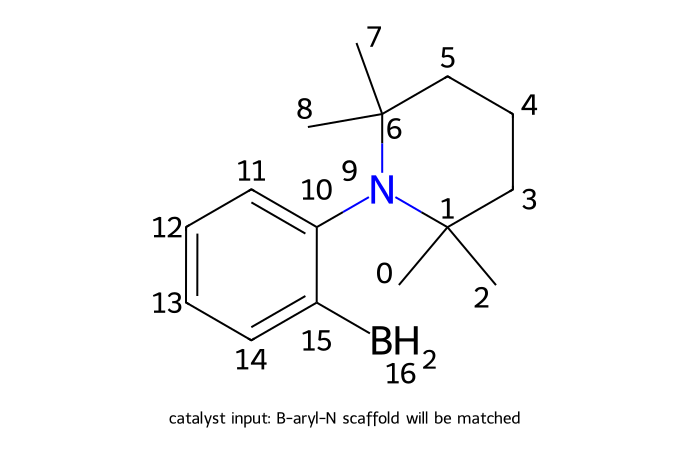

[06:31:46] Molecule does not have explicit Hs. Consider calling AddHs()
[06:31:46] Molecule does not have explicit Hs. Consider calling AddHs()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
substrate_mol = mol_from_smiles(substrate_smiles, label=substrate_name)
catalyst_mol = mol_from_smiles(catalyst_smiles, label=catalyst_name)

draw_2d(substrate_mol, title="substrate input: atom indices define rpos")
draw_2d(catalyst_mol, title="catalyst input: B-aryl-N scaffold will be matched")
show_3d(
    [substrate_mol, catalyst_mol],
    legends=["substrate input", "catalyst input"],
    columns=2,
)

## Step 3. `screen.read`: Normalize The Parts List

`ft.screen.read(...)` turns a loose user-facing table into the normalized
component table. This function owns role aliases, required columns, generated
names, and the rule that `rpos` belongs to substrates rather than catalysts.

In [6]:
components = ft.screen.read(screen_input)

pd.DataFrame(
    [
        {
            "function": function_signature(ft.screen.read),
            "module": "frust/screen/core.py",
            "input object": "screen_input dataframe",
            "output object": "components dataframe",
        }
    ]
)

,function,module,input object,output object
0,"read(input_data: 'str | Path | pd.DataFrame', *, strict: 'bool' = False) -> 'pd.DataFrame'",frust/screen/core.py,screen_input dataframe,components dataframe


In [7]:
components

,role,smiles,compound_name,rpos
0,substrate,CN1C=CC=C1,n_methyl_pyrrole,2
1,catalyst,CC1(C)CCCC(C)(C)N1C2=CC=CC=C2B,tmp_bcat,


## Step 4. `screen.expand`: Make Explicit Systems

The component table is a library. The system table is the actual screen. With
one substrate and one catalyst there is one row, but with 11 substrates and 3
catalysts this step would create 33 substrate/catalyst systems before rpos and
conformer expansion.

In [8]:
systems = ft.screen.expand(components)
system = systems.iloc[0]

systems[["system_name", "substrate_name", "catalyst_name", "substrate_smiles", "catalyst_smiles", "rpos"]]

,system_name,substrate_name,catalyst_name,substrate_smiles,catalyst_smiles,rpos
0,n_methyl_pyrrole__tmp_bcat,n_methyl_pyrrole,tmp_bcat,CN1C=CC=C1,CC1(C)CCCC(C)(C)N1C2=CC=CC=C2B,2


From this point onward, the TS-guess layer works row-by-row. One system row plus
one `rpos` plus one `TSSpec` becomes one or more embedded TS rows.

In [9]:
public_to_private_flow = pd.DataFrame(
    [
        {
            "call": "ft.screen.create_ts_guesses(systems, ts_types=[...])",
            "delegates to": "frust.tsguess.create_ts_guess_dataframes(...)",
            "why": "keeps the public API dataframe-oriented while the construction code stays in tsguess",
        },
        {
            "call": "create_ts_guess_dataframes",
            "delegates to": "_rows_for_system_rpos(system, spec, rpos)",
            "why": "loops over systems, parsed rpos values, TS specs, and conformers",
        },
    ]
)
public_to_private_flow

,call,delegates to,why
0,"ft.screen.create_ts_guesses(systems, ts_types=[...])",frust.tsguess.create_ts_guess_dataframes(...),keeps the public API dataframe-oriented while the construction code stays in tsguess
1,create_ts_guess_dataframes,"_rows_for_system_rpos(system, spec, rpos)","loops over systems, parsed rpos values, TS specs, and conformers"


## Step 5. Choose A Template Specification

A `TSSpec` is the instruction sheet for a TS family. It contains:

- named role coordinates, such as `cat_B`, `pin_B`, and `substrate_C`
- role-based distance and angle constraints
- a legacy `constraint_order` for compatibility
- an optional built-in fragment, such as `HBpin`

This notebook uses `TS3` because it shows most moving parts: catalyst, substrate,
catalyst B-H, HBpin B-H, soft frames, final connectivity, and constraints.

In [10]:
spec = BUILTIN_TS_SPECS[selected_ts]

pd.DataFrame(
    [
        {
            "name": spec.name,
            "spec_id": spec.spec_id,
            "extra_fragment": spec.extra_fragment,
            "constraint_order": ", ".join(spec.constraint_order),
            "n_role_coordinates": len(spec.role_coordinates),
            "n_constraints": len(spec.constraints),
        }
    ]
)

,name,spec_id,extra_fragment,constraint_order,n_role_coordinates,n_constraints
0,TS3,TS3::builtin::methylpyrrole_tmp_v1,HBpin,"cat_B, cat_N, cat_H, pin_B, transfer_H, substrate_C",6,8


In [11]:
pd.DataFrame(
    [
        {
            "role": role,
            "x": round(coords[0], 3),
            "y": round(coords[1], 3),
            "z": round(coords[2], 3),
        }
        for role, coords in spec.role_coordinates.items()
    ]
)

,role,x,y,z
0,cat_B,1.202,0.080,0.660
1,transfer_H,1.677,-1.005,-0.053
2,cat_H,1.583,0.890,-0.137
3,pin_B,2.532,-1.428,0.778
4,substrate_C,1.977,0.249,2.068
5,cat_N,-0.977,1.971,0.016


In [12]:
pd.DataFrame([entry.as_dict() for entry in spec.constraints])

,kind,roles,value
0,distance,"[transfer_H, cat_B]",1.376
1,distance,"[transfer_H, pin_B]",1.264
2,distance,"[transfer_H, substrate_C]",2.477
3,distance,"[cat_B, substrate_C]",1.616
4,distance,"[pin_B, substrate_C]",2.180
5,distance,"[pin_B, cat_B]",2.007
6,angle,"[cat_B, transfer_H, pin_B]",98.890
7,angle,"[cat_B, substrate_C, pin_B]",61.750


In [13]:
template_mol, template_roles = role_template_mol(spec)
show_3d(
    template_mol,
    legends=["TS3 role-coordinate template from TSSpec"],
    highlights=[list(template_roles.values())],
    columns=1,
)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Step 6. Match Chemical Roles Before Assembly

The role matcher makes the chemistry explicit. It finds the catalyst B-aryl-N
motif, validates the substrate `rpos`, and identifies the substrate hydrogen that
must be removed.

The role names are the software contract. Downstream code does not need to know
that `cat_B` happens to be atom index `17` in a particular molecule; it asks the
role map.

In [14]:
catalyst_h = Chem.AddHs(catalyst_mol)
substrate_h = Chem.AddHs(substrate_mol)

valid_rpos = parse_rpos_value(chosen_rpos, substrate_smiles)
cat_roles = match_catalyst_roles(catalyst_h, catalyst_name=catalyst_name)
cat_b_hydrogens = hydrogens_on_atom(catalyst_h, cat_roles["cat_B"], role="cat_B", minimum=1)
leaving_h = substrate_hydrogen_for_rpos(
    substrate_h,
    chosen_rpos,
    substrate_name=substrate_name,
)

pd.DataFrame(
    [
        {"thing found": "valid substrate rpos", "value": valid_rpos},
        {"thing found": "catalyst roles", "value": cat_roles},
        {"thing found": "catalyst B-H atoms", "value": cat_b_hydrogens},
        {"thing found": "substrate H removed later", "value": leaving_h},
    ]
)

,thing found,value
0,valid substrate rpos,"(2,)"
1,catalyst roles,"{'cat_B': 16, 'cat_N': 9}"
2,catalyst B-H atoms,"[39, 40]"
3,substrate H removed later,9


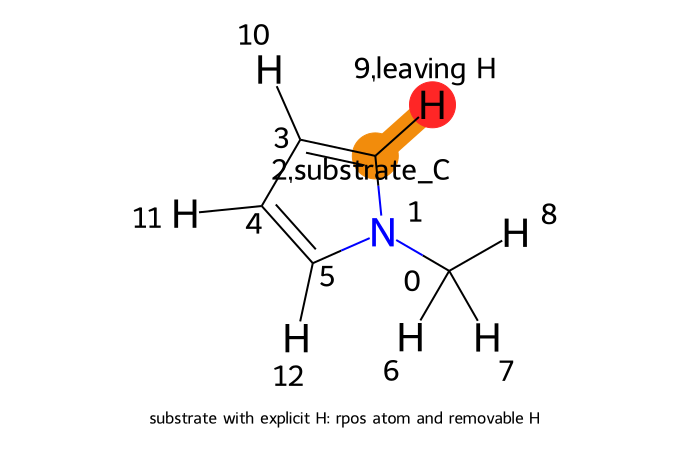

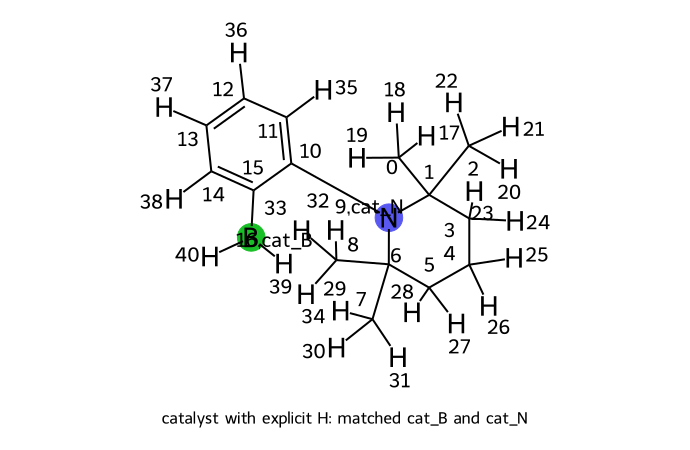

In [15]:
substrate_labels = {chosen_rpos: "substrate_C", leaving_h: "leaving H"}
substrate_highlights = {chosen_rpos: ROLE_COLORS["substrate_C"], leaving_h: (1.0, 0.15, 0.15)}

draw_2d(
    substrate_h,
    title="substrate with explicit H: rpos atom and removable H",
    highlights=substrate_highlights,
    labels=substrate_labels,
)

draw_2d(
    catalyst_h,
    title="catalyst with explicit H: matched cat_B and cat_N",
    highlights=highlight_from_roles(cat_roles),
    labels={idx: role for role, idx in cat_roles.items()},
)

## Step 7. `_assemble_system_mol`: Combine The Parts

`_assemble_system_mol(system, spec, rpos)` is the molecular assembly step. For
`TS3` it does the following:

```text
catalyst SMILES -> explicit H catalyst -> keep one B-H as cat_H
substrate SMILES -> explicit H substrate -> remove the chosen rpos H
extra_fragment='HBpin' -> add built-in HBpin and assign pin_B + transfer_H
combine disconnected fragments -> return combined RDKit Mol + role map
```

The molecule is not yet placed in the template geometry. This is still a bag of
parts with correct atom roles.

In [16]:
assembled, roles = _assemble_system_mol(system, spec, chosen_rpos)

role_table(roles, assembled)

,role,atom_index,element
0,cat_B,16,B
1,cat_H,39,H
2,cat_N,9,N
3,pin_B,56,B
4,substrate_C,42,C
5,transfer_H,67,H


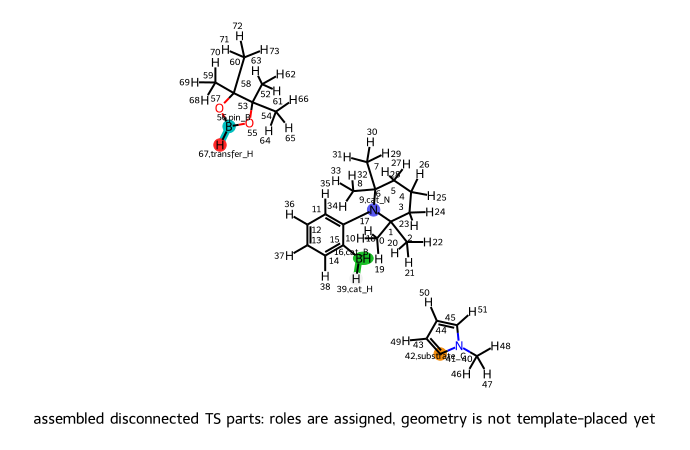

[06:31:46] Molecule does not have explicit Hs. Consider calling AddHs()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [17]:
draw_2d(
    label_roles(assembled, roles),
    title="assembled disconnected TS parts: roles are assigned, geometry is not template-placed yet",
    highlights=highlight_from_roles(roles),
    labels={idx: role for role, idx in roles.items()},
)
show_3d(
    label_roles(assembled, roles),
    legends=["assembled parts before template placement"],
    highlights=[list(roles.values())],
    columns=1,
)

## Step 8. `_placement_coord_map`: Turn Roles Into Anchors

The coordinate map is the bridge between template chemistry and RDKit embedding.
It maps atom indices in the assembled molecule to Cartesian coordinates from the
`TSSpec` and related TMP frame data.

There are two kinds of placement atoms:

- hard anchors: named role atoms snapped exactly to template coordinates
- soft frame anchors: nearby heavy atoms used to orient substrate/HBpin fragments

In [18]:
coord_map = _placement_coord_map(assembled, spec, roles)
hard_atoms = _hard_placement_atom_indices(spec, roles)
role_by_atom = {int(atom_idx): role for role, atom_idx in roles.items()}

coord_map_records = []
for atom_idx, coords in sorted(coord_map.items()):
    atom = assembled.GetAtomWithIdx(int(atom_idx))
    coord_map_records.append(
        {
            "atom_index": int(atom_idx),
            "element": atom.GetSymbol(),
            "role_or_frame": role_by_atom.get(int(atom_idx), "soft frame atom"),
            "anchor_type": "hard role anchor" if int(atom_idx) in hard_atoms else "soft frame anchor",
            "x": round(coords[0], 3),
            "y": round(coords[1], 3),
            "z": round(coords[2], 3),
        }
    )

coord_map_table = pd.DataFrame(coord_map_records)
coord_map_table

,atom_index,element,role_or_frame,anchor_type,x,y,z
0,9,N,cat_N,hard role anchor,-0.977,1.971,0.016
1,16,B,cat_B,hard role anchor,1.202,0.080,0.660
2,39,H,cat_H,hard role anchor,1.583,0.890,-0.137
3,41,N,soft frame atom,soft frame anchor,3.161,1.507,2.236
4,42,C,substrate_C,hard role anchor,1.977,0.249,2.068
5,43,C,soft frame atom,soft frame anchor,1.649,-0.239,3.316
6,55,O,soft frame atom,soft frame anchor,3.839,-1.273,0.412
7,56,B,pin_B,hard role anchor,2.532,-1.428,0.778
8,57,O,soft frame atom,soft frame anchor,2.262,-2.599,1.440
9,67,H,transfer_H,hard role anchor,1.677,-1.005,-0.053


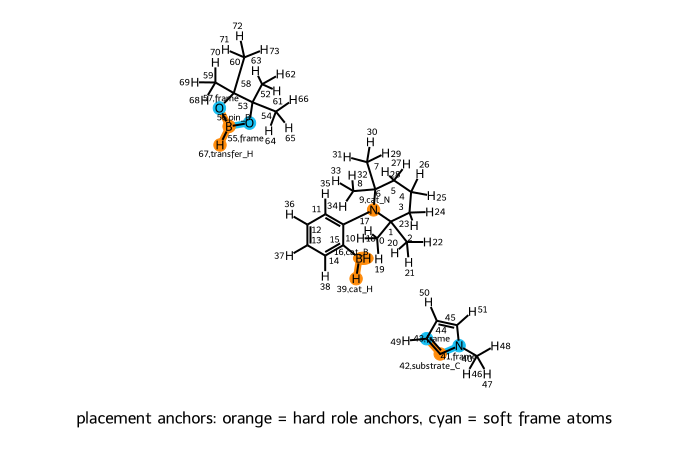

In [19]:
anchor_highlights = {
    int(atom_idx): (HARD_COLOR if int(atom_idx) in hard_atoms else SOFT_COLOR)
    for atom_idx in coord_map
}
anchor_labels = {
    int(atom_idx): role_by_atom.get(int(atom_idx), "frame")
    for atom_idx in coord_map
}

draw_2d(
    assembled,
    title="placement anchors: orange = hard role anchors, cyan = soft frame atoms",
    highlights=anchor_highlights,
    labels=anchor_labels,
)

## Step 9. `embed_with_coord_map`: Build The 3D Guess

The embedder receives the assembled molecule and the coordinate map. If the
molecule has disconnected fragments, it embeds each fragment and rigidly places
fragments from their anchors. Then it snaps the hard role atoms, ranks conformers
by clash score, and returns the best conformer IDs.

In [20]:
embedded, cids = embed_with_coord_map(
    assembled,
    coord_map,
    n_confs=1,
    n_cores=1,
    allowed_contact_pairs=_allowed_contact_pairs(spec, roles),
    snap_atom_indices=hard_atoms,
)

pd.DataFrame(
    [
        {
            "function": function_signature(embed_with_coord_map),
            "n_coord_map_atoms": len(coord_map),
            "n_hard_snap_atoms": len(hard_atoms),
            "conformer_ids": cids,
        }
    ]
)

,function,n_coord_map_atoms,n_hard_snap_atoms,conformer_ids
0,"embed_with_coord_map(mol: 'Chem.Mol', coord_map: 'dict[int, tuple[float, float, float]]', *, n_confs: 'int' = 1, n_cores: 'int' = 1, all...",10,6,[0]


In [21]:
show_3d(
    label_roles(embedded, roles),
    legends=["embedded and template-placed TS3 guess before final stored TS bonds"],
    highlights=[list(coord_map)],
    columns=1,
)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Step 10. `_add_final_ts_bonds`: Store Plotting Connectivity

RDKit embedding works best before some TS graph bonds are added. After embedding,
FRUST adds the TS-specific stored connectivity needed for plotting and downstream
row reconstruction.

For `TS3`, the stored final bond is `cat_B-substrate_C`. The `pin_B-cat_B`
interaction is a constraint/geometry relationship, not a stored covalent bond.

In [22]:
bonded = _add_final_ts_bonds(embedded, spec, roles)
connectivity_bonds = _connectivity_bonds(bonded)

final_role_bonds = []
for left, right in [("cat_B", "substrate_C"), ("pin_B", "cat_B"), ("pin_B", "substrate_C")]:
    if left in roles and right in roles:
        has_bond = bonded.GetBondBetweenAtoms(int(roles[left]), int(roles[right])) is not None
        final_role_bonds.append({"role pair": f"{left}-{right}", "stored as RDKit bond": has_bond})

pd.DataFrame(final_role_bonds)

,role pair,stored as RDKit bond
0,cat_B-substrate_C,True
1,pin_B-cat_B,False
2,pin_B-substrate_C,False


In [23]:
show_3d(
    label_roles(bonded, roles),
    legends=["embedded TS3 guess after final stored connectivity"],
    highlights=[list(roles.values())],
    columns=1,
)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Step 11. `_rows_for_system_rpos`: Pack The FRUST Row

The row is the interface between `tsguess` and the rest of FRUST. It stores the
molecular identity, coordinates, connectivity, role map, constraints, provenance,
and diagnostic core metrics.

This is why `Stepper` does not need fixed TS atom indices. It reads roles and
constraints from the row.

In [24]:
manual_rows = _rows_for_system_rpos(system, spec, chosen_rpos, n_confs=1, n_cores=1)
manual_row = manual_rows[0]

row_contract = pd.DataFrame(
    [
        {"row column": "atoms", "meaning": "atom symbols in dataframe order", "used by": "plotting, XYZ writing, Stepper"},
        {"row column": "coords_embedded", "meaning": "embedded Cartesian coordinates", "used by": "plotting, Stepper input"},
        {"row column": "connectivity_bonds", "meaning": "stored bond graph", "used by": "row-to-RDKit reconstruction"},
        {"row column": "constraint_roles", "meaning": "role name -> atom index", "used by": "constraint rendering and inspection"},
        {"row column": "constraint_spec", "meaning": "role-level distances/angles", "used by": "render_xtb_constraints and Stepper"},
        {"row column": "constraint_atoms", "meaning": "legacy role order projection", "used by": "backward compatibility"},
        {"row column": "ts_core_metrics", "meaning": "measured deltas from template constraints", "used by": "diagnostics"},
    ]
)
row_contract

,row column,meaning,used by
0,atoms,atom symbols in dataframe order,"plotting, XYZ writing, Stepper"
1,coords_embedded,embedded Cartesian coordinates,"plotting, Stepper input"
2,connectivity_bonds,stored bond graph,row-to-RDKit reconstruction
3,constraint_roles,role name -> atom index,constraint rendering and inspection
4,constraint_spec,role-level distances/angles,render_xtb_constraints and Stepper
5,constraint_atoms,legacy role order projection,backward compatibility
6,ts_core_metrics,measured deltas from template constraints,diagnostics


In [25]:
pd.DataFrame(
    [
        {
            "custom_name": manual_row["custom_name"],
            "structure_type": manual_row["structure_type"],
            "ts_spec_id": manual_row["ts_spec_id"],
            "n_atoms": len(manual_row["atoms"]),
            "n_bonds": len(manual_row["connectivity_bonds"]),
            "n_roles": len(manual_row["constraint_roles"]),
            "n_constraints": len(manual_row["constraint_spec"]),
        }
    ]
)

,custom_name,structure_type,ts_spec_id,n_atoms,n_bonds,n_roles,n_constraints
0,TS3(n_methyl_pyrrole__tmp_bcat_rpos(2)),TS3,TS3::builtin::methylpyrrole_tmp_v1,74,76,6,8


In [26]:
role_table(manual_row["constraint_roles"], _row_to_mol(manual_row, manual_row["atoms"], manual_row["coords_embedded"]))

,role,atom_index,element
0,cat_B,16,B
1,cat_H,39,H
2,cat_N,9,N
3,pin_B,56,B
4,substrate_C,42,C
5,transfer_H,67,H


## Step 12. The Public API Does The Same Assembly

The public call below runs the same pipeline without exposing the private helper
functions. This is what users should normally call from notebooks and scripts.

In [27]:
ts_guesses = ft.screen.create_ts_guesses(
    systems,
    ts_types=["TS1", "TS2", "TS3", "TS4"],
    n_confs=1,
)

public_row = ts_guesses[selected_ts].iloc[0]

pd.DataFrame(
    [
        {
            "ts_type": ts_type,
            "rows": len(df),
            "example custom_name": df.iloc[0]["custom_name"],
            "row columns": len(df.columns),
        }
        for ts_type, df in ts_guesses.items()
    ]
)

,ts_type,rows,example custom_name,row columns
0,TS1,1,TS1(n_methyl_pyrrole__tmp_bcat_rpos(2)),21
1,TS2,1,TS2(n_methyl_pyrrole__tmp_bcat_rpos(2)),21
2,TS3,1,TS3(n_methyl_pyrrole__tmp_bcat_rpos(2)),21
3,TS4,1,TS4(n_methyl_pyrrole__tmp_bcat_rpos(2)),21


In [28]:
comparison = pd.DataFrame(
    [
        {
            "field": "constraint_roles",
            "manual helper row": manual_row["constraint_roles"],
            "public API row": public_row["constraint_roles"],
            "same": manual_row["constraint_roles"] == public_row["constraint_roles"],
        },
        {
            "field": "constraint_atoms",
            "manual helper row": manual_row["constraint_atoms"],
            "public API row": public_row["constraint_atoms"],
            "same": manual_row["constraint_atoms"] == public_row["constraint_atoms"],
        },
    ]
)
comparison

,field,manual helper row,public API row,same
0,constraint_roles,"{'cat_B': 16, 'cat_N': 9, 'substrate_C': 42, 'cat_H': 39, 'pin_B': 56, 'transfer_H': 67}","{'cat_B': 16, 'cat_N': 9, 'substrate_C': 42, 'cat_H': 39, 'pin_B': 56, 'transfer_H': 67}",True
1,constraint_atoms,"[16, 9, 39, 56, 67, 42]","[16, 9, 39, 56, 67, 42]",True


In [29]:
show_3d(
    row_to_role_mol(public_row),
    legends=["public ft.screen.create_ts_guesses TS3 row"],
    highlights=[list(public_row["constraint_roles"].values())],
    columns=1,
)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Step 13. Diagnostics And Constraints Are Role-Based

`constraint_spec` stores role names. At render time, FRUST projects those role
names through `constraint_roles` to actual atom indices for the generated row.
That is the important software design: the template is chemically named, not
fixed to one static atom order.

In [30]:
constraint_table(public_row)

,kind,roles,atoms,target,measured,delta
0,distance,transfer_H-cat_B,67-16,1.376,1.382,0.006
1,distance,transfer_H-pin_B,67-56,1.264,1.265,0.001
2,distance,transfer_H-substrate_C,67-42,2.477,2.482,0.005
3,distance,cat_B-substrate_C,16-42,1.616,1.616,0.000
4,distance,pin_B-substrate_C,56-42,2.180,2.188,0.008
5,distance,pin_B-cat_B,56-16,2.007,2.015,0.008
6,angle,cat_B-transfer_H-pin_B,16-67-56,98.890,99.031,0.141
7,angle,cat_B-substrate_C-pin_B,16-42-56,61.750,61.825,0.075


In [31]:
print(render_xtb_constraints(public_row))

$constrain
force constant=50
distance: 68, 17, 1.376
distance: 68, 57, 1.264
distance: 68, 43, 2.477
distance: 17, 43, 1.616
distance: 57, 43, 2.18
distance: 57, 17, 2.007
angle: 17, 68, 57, 98.89
angle: 17, 43, 57, 61.75
$end


In [32]:
pd.DataFrame(public_row["ts_core_metrics"])

,kind,roles,reference,measured,delta
0,distance,"[transfer_H, cat_B]",1.376,1.382447,0.006447
1,distance,"[transfer_H, pin_B]",1.264,1.265143,0.001143
2,distance,"[transfer_H, substrate_C]",2.477,2.481990,0.004990
3,distance,"[cat_B, substrate_C]",1.616,1.616321,0.000321
4,distance,"[pin_B, substrate_C]",2.180,2.188227,0.008227
5,distance,"[pin_B, cat_B]",2.007,2.015153,0.008153
6,angle,"[cat_B, transfer_H, pin_B]",98.890,99.031373,0.141373
7,angle,"[cat_B, substrate_C, pin_B]",61.750,61.824990,0.074990


## Step 14. TS1-TS4 Share The Same Architecture

Different TS families use different `TSSpec` objects and slightly different
assembly rules, but the row contract is the same. That is why downstream FRUST
code can consume all four TS types as ordinary initial dataframes.

In [33]:
rows = [ts_guesses[ts].iloc[0] for ts in ["TS1", "TS2", "TS3", "TS4"]]
summary_rows = []
for row in rows:
    summary_rows.append(
        {
            "ts_type": row["structure_type"],
            "ts_spec_id": row["ts_spec_id"],
            "roles": ", ".join(row["constraint_roles"].keys()),
            "extra_fragment": BUILTIN_TS_SPECS[row["structure_type"]].extra_fragment,
            "n_constraints": len(row["constraint_spec"]),
            "n_atoms": len(row["atoms"]),
        }
    )

pd.DataFrame(summary_rows)

,ts_type,ts_spec_id,roles,extra_fragment,n_constraints,n_atoms
0,TS1,TS1::builtin::methylpyrrole_v1,"cat_B, cat_N, substrate_C, transfer_H",H,7,54
1,TS2,TS2::builtin::methylpyrrole_v1,"cat_B, cat_N, substrate_C, cat_H, n_transfer_H, transfer_H",H2,4,54
2,TS3,TS3::builtin::methylpyrrole_tmp_v1,"cat_B, cat_N, substrate_C, cat_H, pin_B, transfer_H",HBpin,8,74
3,TS4,TS4::builtin::methylpyrrole_tmp_v1,"cat_B, cat_N, substrate_C, cat_H, transfer_H, pin_B",HBpin,8,74


In [34]:
final_mols = [row_to_role_mol(row) for row in rows]
final_highlights = [list(row["constraint_roles"].values()) for row in rows]
final_legends = [
    "TS1: single transfer H",
    "TS2: H-H motif",
    "TS3: HBpin B-H transfer",
    "TS4: catalyst B-H transfer",
]

ft.MolTo3DGrid(
    final_mols,
    legends=final_legends,
    highlightAtoms=final_highlights,
    show_labels=True,
    show_confs=False,
    columns=2,
    linked=True,
    cell_size=(540, 460),
    kekulize=True,
    show_charges=True,
)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Step 15. How `Stepper` Talks To This Row

`Stepper.xtb(..., constraint=True)` does not need to know TS3 chemistry. It sees
an ordinary FRUST row with atoms and coordinates, then asks the constraint
renderer to translate role-level constraints into engine input.

```text
row["atoms"] + row["coords_embedded"]        -> molecular input
row["constraint_roles"] + row["constraint_spec"] -> constrained distances/angles
row["custom_name"] and metadata              -> result/provenance labels
```

This is the architectural reason the new system can screen catalysts: the TS
construction complexity is isolated in `frust.tsguess`, while `Stepper` remains a
row processor.

In [35]:
stepper_contract = pd.DataFrame(
    [
        {"Stepper needs": "atoms", "from row": len(public_row["atoms"]), "why": "write molecular input"},
        {"Stepper needs": "coords_embedded", "from row": f"{len(public_row['coords_embedded'])} coordinate rows", "why": "write starting geometry"},
        {"Stepper needs": "constraint_roles", "from row": public_row["constraint_roles"], "why": "map role names to atom indices"},
        {"Stepper needs": "constraint_spec", "from row": f"{len(public_row['constraint_spec'])} constraints", "why": "render engine constraints"},
    ]
)
stepper_contract

,Stepper needs,from row,why
0,atoms,74,write molecular input
1,coords_embedded,74 coordinate rows,write starting geometry
2,constraint_roles,"{'cat_B': 16, 'cat_N': 9, 'substrate_C': 42, 'cat_H': 39, 'pin_B': 56, 'transfer_H': 67}",map role names to atom indices
3,constraint_spec,8 constraints,render engine constraints


## One-Screen Summary

```text
CSV/dataframe
  -> ft.screen.read
      normalize component rows
  -> ft.screen.expand
      make substrate/catalyst systems
  -> ft.screen.create_ts_guesses
      delegate to frust.tsguess
  -> TSSpec + matching + assembly
      assign roles and combine fragments
  -> coord_map + embed_with_coord_map
      place fragments on the template frame
  -> final bonds + diagnostics
      store connectivity and measure core quality
  -> FRUST row
      Stepper can optimize with role-based constraints
```

The old transformer and the new `tsguess` module share the same scientific idea:
use a known good TS template to build a chemically sensible guess. The new module
moves the template from a fixed atom-order XYZ workflow into named roles,
SMILES-derived fragments, and dataframe rows, so related catalysts and substrates
can be screened without hard-coded atom indices.